In [1]:
# Cell 1 — Env vars and imports
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
# Cell 2 — SoftPermutationMix module definition
# Core idea: parameterize the mixing matrix as a convex combination of K
# permutation matrices. Weights (alpha) are learned via softmax.
# This GUARANTEES doubly stochastic output by construction (mHC-lite principle).

class SoftPermutationMix(nn.Module):
    def __init__(self, dim, K=4):
        super().__init__()
        self.dim = dim
        self.K = K
        # Only the K weights are learned — permutations themselves are fixed random
        self.alpha_logits = nn.Parameter(torch.zeros(K))

        # Generate K fixed random permutation matrices
        perms = [torch.eye(dim)[torch.randperm(dim)] for _ in range(K)]
        self.register_buffer("perms", torch.stack(perms))  # (K, dim, dim)

    def get_mixing_matrix(self):
        # softmax ensures alpha >= 0 and sum(alpha) = 1
        alpha = torch.softmax(self.alpha_logits, dim=0)       # (K,)
        D = torch.einsum("k,kij->ij", alpha, self.perms)      # (dim, dim)
        return D

    def forward(self, x):
        D = self.get_mixing_matrix()
        return x @ D.T

    def get_alpha(self):
        return torch.softmax(self.alpha_logits, dim=0).detach().cpu().numpy()

In [3]:
# Cell 3 — Unit test: verify doubly stochastic property
dim = 16
mixer = SoftPermutationMix(dim=dim, K=4).to(device)
D = mixer.get_mixing_matrix().detach().cpu().numpy()

print("Mixing matrix shape:", D.shape)
print("Row sums:", D.sum(axis=1).round(6))   # should all be 1.0
print("Col sums:", D.sum(axis=0).round(6))   # should all be 1.0
print("All entries >= 0:", (D >= 0).all())
print("Doubly stochastic: PASS ✓" if np.allclose(D.sum(1), 1) and np.allclose(D.sum(0), 1) else "FAIL ✗")

Mixing matrix shape: (16, 16)
Row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Col sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
All entries >= 0: True
Doubly stochastic: PASS ✓


In [4]:
# Cell 4 — Unit test: signal norm preservation
# A doubly stochastic matrix applied to a vector should not inflate its L1 norm
torch.manual_seed(0)
x = torch.rand(100, dim).to(device)
y = mixer(x)

x_l1 = x.abs().sum(dim=1).mean().item()
y_l1 = y.abs().sum(dim=1).mean().item()

print(f"Input  mean L1 norm: {x_l1:.4f}")
print(f"Output mean L1 norm: {y_l1:.4f}")
print(f"Ratio (should be ~1.0): {y_l1/x_l1:.4f}")

Input  mean L1 norm: 7.9325
Output mean L1 norm: 7.9325
Ratio (should be ~1.0): 1.0000


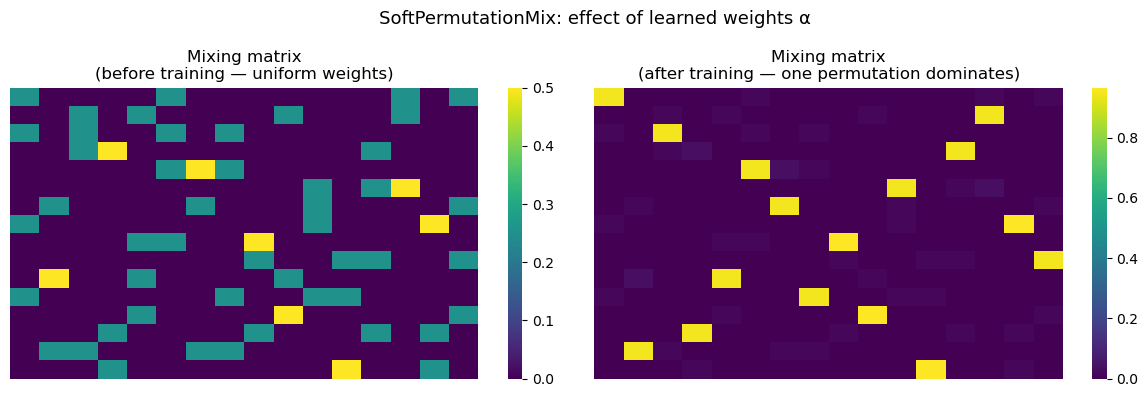


Learned α after simulated training: [0.948 0.017 0.017 0.017]


In [7]:
# Cell 5 — Visualize the initial mixing matrix and how it evolves after fake training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reinitialize cleanly on device for visualization
mixer = SoftPermutationMix(dim=16, K=4).to(device)   # ← add this line

# Before training
D_before = mixer.get_mixing_matrix().detach().cpu().numpy()
sns.heatmap(D_before, ax=axes[0], cmap="viridis",
            xticklabels=False, yticklabels=False)
axes[0].set_title("Mixing matrix\n(before training — uniform weights)")

# Simulate learning by manually pushing alpha_logits
with torch.no_grad():
    mixer.alpha_logits.copy_(torch.tensor([3.0, -1.0, -1.0, -1.0]).to(device))  # ← add .to(device)

D_after = mixer.get_mixing_matrix().detach().cpu().numpy()
sns.heatmap(D_after, ax=axes[1], cmap="viridis",
            xticklabels=False, yticklabels=False)
axes[1].set_title("Mixing matrix\n(after training — one permutation dominates)")

plt.suptitle("SoftPermutationMix: effect of learned weights α", fontsize=13)
plt.tight_layout()
plt.savefig("02_mixing_matrix_evolution.png", dpi=150)
plt.show()

print("\nLearned α after simulated training:", mixer.get_alpha().round(3))